In [2]:
    # objective: generate the particle size structure for the CMIP6 models
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import matplotlib
from matplotlib import pyplot as plt
import xarray as xr
import pandas as pd
import cartopy
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import glob,os,subprocess
from glob import glob
import IPython.display as display
from datetime import datetime as dt
%matplotlib inline
from scipy.stats import linregress
import math

In [13]:
#import data and create dictionary
# create a dictionary with the datasets
file_list_biovol = glob('/Users/mc4214/CMIP6_biome_PSS_data/*biovolume.nc')
file_list_biovol = [x for x in file_list_biovol if 'biovolume' in x and 'old' not in x and 'hist' in x]
file_list_biovol

['/Users/mc4214/CMIP6_biome_PSS_data/biom_CNRM_PSS_hist_biovolume.nc',
 '/Users/mc4214/CMIP6_biome_PSS_data/biom_IPSL_PSS_hist_biovolume.nc',
 '/Users/mc4214/CMIP6_biome_PSS_data/biom_GFDL_PSS_hist_biovolume.nc',
 '/Users/mc4214/CMIP6_biome_PSS_data/biom_CESM_PSS_hist_biovolume.nc',
 '/Users/mc4214/CMIP6_biome_PSS_data/biom_UKESM_PSS_hist_biovolume.nc',
 '/Users/mc4214/CMIP6_biome_PSS_data/biom_GISS_PSS_hist_biovolume.nc',
 '/Users/mc4214/CMIP6_biome_PSS_data/biom_CMCC_PSS_hist_biovolume.nc']

In [4]:
#import data and create dictionary
# create a dictionary with the datasets
file_list_biovol_ssp5 = glob('/Users/mc4214/CMIP6_biome_PSS_data/*biovolume.nc')
file_list_biovol_ssp5 = [x for x in file_list_biovol_ssp5 if 'biovolume' in x and 'old' not in x and 'ssp5' in x]
file_list_biovol_ssp5

['/Users/mc4214/CMIP6_biome_PSS_data/biom_CESM_PSS_ssp5_biovolume.nc',
 '/Users/mc4214/CMIP6_biome_PSS_data/biom_CNRM_PSS_ssp5_biovolume.nc',
 '/Users/mc4214/CMIP6_biome_PSS_data/biom_GFDL_PSS_ssp5_biovolume.nc',
 '/Users/mc4214/CMIP6_biome_PSS_data/biom_IPSL_PSS_ssp5_biovolume.nc',
 '/Users/mc4214/CMIP6_biome_PSS_data/biom_GISS_PSS_ssp5_biovolume.nc',
 '/Users/mc4214/CMIP6_biome_PSS_data/biom_CMCC_PSS_ssp5_biovolume.nc',
 '/Users/mc4214/CMIP6_biome_PSS_data/biom_UKESM_PSS_ssp5_biovolume.nc']

In [14]:
models = ['CESM', 'CMCC', 'CNRM', 'GFDL', 'GISS', 'IPSL', 'UKESM']
# Creating an empty dictionary
NBSS_dict_full = {}
for m in models:
    filename = [x for x in file_list_biovol if m in x][0]
    ds_hist = xr.open_mfdataset(filename)
    nb_med = ds_hist['NB'].median(dim=('time', 'lat', 'lon'), skipna=True)
    df_nb_med = (
    nb_med
      .rename({'biovol_um3': 'bin_centers_biovol'})  # coord name
      .rename('NB')                                   # data/column name
      .to_series()
      .rename_axis('bin_centers_biovol')
      .reset_index()
       )
    NBSS_dict_full[m] = df_nb_med
    

In [5]:
models = ['CESM', 'CMCC', 'CNRM', 'GFDL', 'GISS', 'IPSL', 'UKESM']
# Creating an empty dictionary
NBSS_dict_full_ssp5 = {}
for m in models:
    filename = [x for x in file_list_biovol_ssp5 if m in x][0]
    ds_ssp5 = xr.open_mfdataset(filename)
    nb_med = ds_ssp5['NB'].median(dim=('time', 'lat', 'lon'), skipna=True)
    df_nb_med = (
    nb_med
      .rename({'biovol_um3': 'bin_centers_biovol'})  # coord name
      .rename('NB')                                   # data/column name
      .to_series()
      .rename_axis('bin_centers_biovol')
      .reset_index()
       )
    NBSS_dict_full_ssp5[m] = df_nb_med
    

KeyboardInterrupt: 

In [ ]:
NBSS_dict_full_ssp5['CESM']

In [6]:
#data from Table 3
coeff_df= pd.read_csv('/Users/mc4214/GIT/CMIP6_size_spectra/data/Table_3.csv')
#source = ['CESM', 'CMCC', 'CNRM', 'GFDL', 'GISS', 'IPSL', 'UKESM', 'PSSdb']
#slope = [-1.07, -1.15, -1.24, -1.15, -1.66, -1.27, -1.19, -1.05]
#intercept = [2.03e13, 3.89e13, 4.09e14, 9.32e14, 4.31e17, 4.02e14, 1.72e14, 3.70e13]
#coeff_df = pd.DataFrame({
#    'source': source,
#    'slope': slope,
#    'intercept': intercept
#})
table_S8_df =coeff_df[coeff_df.experiment=='hist']
table_S8_df

,models,experiment,median_slope,min_slope,max_slope,median_intercept,min_intercept,max_intercept,median_biovolume,min_biovolume,max_biovolume,median_R2,min_R2,max_R2,median_Allbiovolume,min_Allbiovolume,max_Allbiovolume
0,CESM,hist,-1.066118,-1.466350,-0.264979,2.028376e+13,7.270048e+06,1.268659e+15,3.088375e+13,1.781244e+10,3.372568e+14,0.981577,0.336143,0.999719,4.554223e+14,3.910081e+11,6.109840e+16
2,CMCC,hist,-1.145756,-1.414426,-0.964676,3.888084e+13,2.765178e+10,3.987648e+14,4.956904e+13,1.810932e+11,4.244137e+15,0.989522,0.881702,0.996663,2.790459e+14,7.222574e+11,1.756437e+16
4,CNRM,hist,-1.242919,-1.470693,-0.865880,4.088973e+14,8.347489e+12,6.734215e+15,2.401478e+13,1.132971e+12,6.015158e+15,0.932526,0.771298,0.983404,9.631971e+15,8.220809e+14,2.045404e+18
6,GFDL,hist,-1.154270,-1.381293,-0.902864,9.319725e+14,1.369770e+08,3.392084e+16,1.692542e+14,4.148979e+09,1.614386e+15,0.990145,0.912846,0.998057,1.174877e+16,1.450193e+10,7.886490e+17
8,GISS,hist,-1.661466,-3.454392,-0.662548,4.305864e+17,1.071894e+10,1.301075e+22,1.075037e+13,1.218806e+02,4.798641e+14,0.948866,0.737606,0.996211,8.666663e+16,2.095738e+11,1.032438e+19
10,IPSL,hist,-1.270359,-1.479045,-1.057045,4.021846e+14,9.577349e+12,1.043512e+16,1.546230e+13,7.709334e+11,2.817074e+14,0.933679,0.764739,0.977038,7.047032e+15,7.136052e+14,1.158334e+18
12,UKESM,hist,-1.193493,-2.808519,-0.948201,1.718096e+14,3.739233e+10,9.829720e+15,2.188143e+13,1.305079e+02,3.518740e+14,0.985188,0.846083,0.995893,6.559373e+14,2.579065e+11,8.987511e+15


In [8]:
## new suggested method: get the integral between 116-2000 um
def biovolume_integral(m, b, x1, x2):
    """Area under y=b*x^m vs x (total biovolume per m^2) over [x1,x2]."""
    if math.isclose(m, -1.0, rel_tol=1e-12):
        # Limit as m→-1 is b*ln(x2/x1)
        return b * math.log(x2/x1)
    return (b/(m+1)) * (x2**(m+1) - x1**(m+1))

In [9]:
# apply this to the coeff_df
x1, x2 = 8.2e5, 4.2e9 # size range in biovolume units

x1, x2 = 8.2e5, 4.2e9

table_S8_df['integrated_biovolume']=table_S8_df.apply(lambda r: biovolume_integral(r['median_slope'], r['median_intercept'], x1, x2),axis=1)
coeff_df['integrated_biovolume']=coeff_df.apply(lambda r: biovolume_integral(r['median_slope'], r['median_intercept'], x1, x2),axis=1)

coeff_df

,models,experiment,median_slope,min_slope,max_slope,median_intercept,min_intercept,max_intercept,median_biovolume,min_biovolume,max_biovolume,median_R2,min_R2,max_R2,median_Allbiovolume,min_Allbiovolume,max_Allbiovolume,integrated_biovolume
0,CESM,hist,-1.066118,-1.466350,-0.264979,2.028376e+13,7.270048e+06,1.268659e+15,3.088375e+13,1.781244e+10,3.372568e+14,0.981577,0.336143,0.999719,4.554223e+14,3.910081e+11,6.109840e+16,5.380058e+13
1,CESM,ssp5,-1.067569,-1.307257,-0.046528,1.922066e+13,1.161267e+04,1.141477e+15,2.927907e+13,2.335715e+11,2.456715e+14,0.985467,0.070298,0.999523,4.151373e+14,1.470390e+12,5.482285e+16,4.970366e+13
2,CMCC,hist,-1.145756,-1.414426,-0.964676,3.888084e+13,2.765178e+10,3.987648e+14,4.956904e+13,1.810932e+11,4.244137e+15,0.989522,0.881702,0.996663,2.790459e+14,7.222574e+11,1.756437e+16,2.609997e+13
3,CMCC,ssp5,-1.151974,-1.574241,-0.990044,3.799232e+13,3.226165e+10,5.319332e+14,4.185275e+13,2.441198e+11,4.377844e+15,0.989866,0.885792,0.996479,2.456197e+14,9.465377e+11,1.812783e+16,2.294426e+13
4,CNRM,hist,-1.242919,-1.470693,-0.865880,4.088973e+14,8.347489e+12,6.734215e+15,2.401478e+13,1.132971e+12,6.015158e+15,0.932526,0.771298,0.983404,9.631971e+15,8.220809e+14,2.045404e+18,5.386373e+13
5,CNRM,ssp5,-1.262700,-1.445094,-1.120305,4.164689e+14,8.644617e+12,6.789735e+15,1.794857e+13,2.342286e+12,5.439676e+14,0.933893,0.767820,0.979471,8.833454e+15,7.213597e+14,2.599593e+18,3.961646e+13
6,GFDL,hist,-1.154270,-1.381293,-0.902864,9.319725e+14,1.369770e+08,3.392084e+16,1.692542e+14,4.148979e+09,1.614386e+15,0.990145,0.912846,0.998057,1.174877e+16,1.450193e+10,7.886490e+17,5.413203e+14
7,GFDL,ssp5,-1.158388,-1.352429,-0.901950,8.297480e+14,1.967755e+08,3.266435e+16,1.466179e+14,3.873883e+09,1.517562e+15,0.991315,0.918141,0.997936,9.757644e+15,1.741287e+10,7.774469e+17,4.494255e+14
8,GISS,hist,-1.661466,-3.454392,-0.662548,4.305864e+17,1.071894e+10,1.301075e+22,1.075037e+13,1.218806e+02,4.798641e+14,0.948866,0.737606,0.996211,8.666663e+16,2.095738e+11,1.032438e+19,7.947574e+13
9,GISS,ssp5,-1.675853,-3.593988,-0.824533,4.205596e+17,2.518112e+11,2.966505e+22,7.606460e+12,1.817091e+01,3.683292e+14,0.947820,0.855214,0.996207,8.183699e+16,3.205111e+10,1.091970e+19,6.248189e+13


In [19]:
#Now get analytical estimate of the biovolume for PSSbd:
df_pssdb = pd.read_csv('/Users/mc4214/Documents/CMIP6_PSS_paper/data/PSSdb_data/PSSdb_data_full.csv', sep= ',')
x1, x2 = 8.2e5, 4.2e9 # size range in biovolume units
#int_biovol = biovolume_integral(np.nanmedian(df_pssdb.slope), np.nanmedian(10**(df_pssdb.intercept)), x1, x2)
int_biovol = biovolume_integral(-1.046, 4.655923e13, x1, x2)
print(f"{int_biovol:2e}")
#print(np.nanmedian(df_pssdb.slope))
#print(f"{np.nanmedian(10**df_pssdb.intercept):2e}")

1.757789e+14


In [25]:
PSSdb_1a_files = glob('/Users/mc4214/Documents/CMIP6_PSS_paper/data/PSSdb_data/*1a*.csv')
df_pssdb = pd.read_csv('/Users/mc4214/Documents/CMIP6_PSS_paper/data/PSSdb_data/PSSdb_data_full.csv', sep= ',')
PSSdb_1a_files = [x for x in PSSdb_1a_files if 'IFCB' not in x]

In [26]:
df_pssdb

,lat,lon,biomes,month,slope,intercept,R2,total_biovolume,season,experiment,source
0,80.5,69.5,HCSS,8.0,-0.71160,10.534895,0.94760,6.169158e+14,Summer,obs,PSSdb
1,79.5,60.5,HCSS,8.0,-1.01360,13.587905,0.96615,1.303313e+15,Summer,obs,PSSdb
2,79.5,66.5,HCSS,7.0,-0.72790,11.050613,0.86505,1.907347e+15,Summer,obs,PSSdb
3,79.5,69.5,HCSS,8.0,-0.82940,12.245196,0.98330,1.266103e+15,Summer,obs,PSSdb
4,79.5,71.5,HCSS,7.0,-0.68490,10.892050,0.95075,2.019704e+15,Summer,obs,PSSdb
...,...,...,...,...,...,...,...,...,...,...,...
1211,-57.5,-67.5,HCSS,7.0,-0.58180,9.593316,0.90310,5.395755e+14,Summer,obs,PSSdb
1212,-60.5,-60.5,HCSS,7.0,-1.01455,13.387113,0.94335,1.199266e+15,Summer,obs,PSSdb
1213,-62.5,-49.5,HCSS,7.0,-0.64370,7.890369,0.97900,4.157971e+14,Summer,obs,PSSdb
1214,-64.5,-53.5,HCSS,7.0,-0.72810,11.329196,0.94540,1.274523e+15,Summer,obs,PSSdb


In [15]:
PSSdb_1a_files

['/Users/mc4214/Documents/CMIP6_PSS_paper/data/PSSdb_data/UVP_1a_Size-distribution_v2024-04.csv',
 '/Users/mc4214/Documents/CMIP6_PSS_paper/data/PSSdb_data/Scanner_1a_Size-distribution_v2024-04.csv']

In [16]:
PSSdb_1a_files

['/Users/mc4214/Documents/CMIP6_PSS_paper/data/PSSdb_data/UVP_1a_Size-distribution_v2024-04.csv',
 '/Users/mc4214/Documents/CMIP6_PSS_paper/data/PSSdb_data/Scanner_1a_Size-distribution_v2024-04.csv']

In [40]:
df_1a=pd.concat(map((lambda path: (pd.read_csv(path))), PSSdb_1a_files)).reset_index(drop=True)
df_1a['normalized_biovolume_mean_depth_int'] = (df_1a['normalized_biovolume_mean']/0.001)* df_1a['max_depth']# depth integrtation, remember values go from liters to squared meters

In [41]:
#add biomes labels to df_1a
biome_map = (
    df_pssdb
      .groupby(['lat','lon'], as_index=False)['biomes']
      .agg(lambda s: s.mode().iat[0] if not s.mode().empty else s.iloc[0])
)

df_1a = (
    df_1a
      .merge(biome_map, left_on=['latitude','longitude'], right_on=['lat','lon'], how='left')
      .drop(columns=['lat','lon'])
)

In [42]:
df_1a_summary=df_1a.astype(dict(zip(['biovolume_size_class'],[str]*1))).groupby(['biovolume_size_class', 'biomes']).apply(lambda x: pd.Series({'NB':np.nanmedian(x.normalized_biovolume_mean_depth_int)})).reset_index()


In [43]:
df_1a_summary = (
    df_1a_summary
      .rename(columns={'biovolume_size_class': 'bin_centers_biovol'})
      .assign(bin_centers_biovol=lambda d: pd.to_numeric(d['bin_centers_biovol'], errors='coerce'))
      .sort_values('bin_centers_biovol')
      .reset_index(drop=True)
)
df_1a_summary
NBSS_dict_full['PSSdb'] = df_1a_summary

In [44]:
NBSS_dict_full['PSSdb']

,bin_centers_biovol,biomes,NB
0,8.235000e+05,LC,1.384500e+05
1,8.235000e+05,HCSS,1.586694e+08
2,8.235000e+05,HCPS,1.330000e+05
3,1.647000e+06,LC,9.670000e+04
4,1.647000e+06,HCPS,1.463280e+07
...,...,...,...
70,6.908000e+12,HCSS,3.005060e+02
71,1.382000e+13,HCSS,1.549115e+02
72,1.382000e+13,HCPS,1.303290e+02
73,2.763000e+13,HCSS,5.290990e+02


In [45]:
NBSS_dict_full['PSSdb'].bin_centers_biovol.unique()

array([8.235e+05, 1.647e+06, 3.294e+06, 6.588e+06, 1.318e+07, 2.635e+07,
       5.271e+07, 1.054e+08, 2.108e+08, 4.217e+08, 8.433e+08, 1.687e+09,
       3.373e+09, 6.747e+09, 1.349e+10, 2.699e+10, 5.397e+10, 1.079e+11,
       2.159e+11, 4.318e+11, 8.636e+11, 1.727e+12, 3.454e+12, 6.908e+12,
       1.382e+13, 2.763e+13])

In [48]:
# NB per biome/bin
df_nb = NBSS_dict_full['PSSdb'].copy()  # cols: bin_centers_biovol, biomes, NB

# Biome areas (or use your existing df_area with same columns)
areas = pd.DataFrame({
    'biomes': ['HCPS', 'HCSS', 'LC'],
    'area_km2': [7.530620e+07, 1.434293e+08, 1.332794e+08]
})

# Attach weights
df_nb = df_nb.merge(areas, on='biomes', how='left', validate='m:1')

# Weighted mean using only biomes present in each bin (row-wise denominator)
df_nb_weighted = (
    df_nb.assign(wNB = df_nb['NB'] * df_nb['area_km2'])
         .groupby('bin_centers_biovol')
         .agg(NB_wsum=('wNB','sum'), wsum=('area_km2','sum'))
         .assign(NB=lambda d: d['NB_wsum'] / d['wsum'])
         .reset_index()[['bin_centers_biovol','NB']]
)
NBSS_dict_full['PSSdb'] = df_nb_weighted

In [36]:
df_nb_weighted.bin_centers_biovol.unique()

array([8.235e+05, 1.647e+06, 3.294e+06, 6.588e+06, 1.318e+07, 2.635e+07,
       5.271e+07, 1.054e+08, 2.108e+08, 4.217e+08, 8.433e+08, 1.687e+09,
       3.373e+09, 6.747e+09, 1.349e+10, 2.699e+10, 5.397e+10, 1.079e+11,
       2.159e+11, 4.318e+11, 8.636e+11, 1.727e+12, 3.454e+12, 6.908e+12,
       1.382e+13, 2.763e+13])

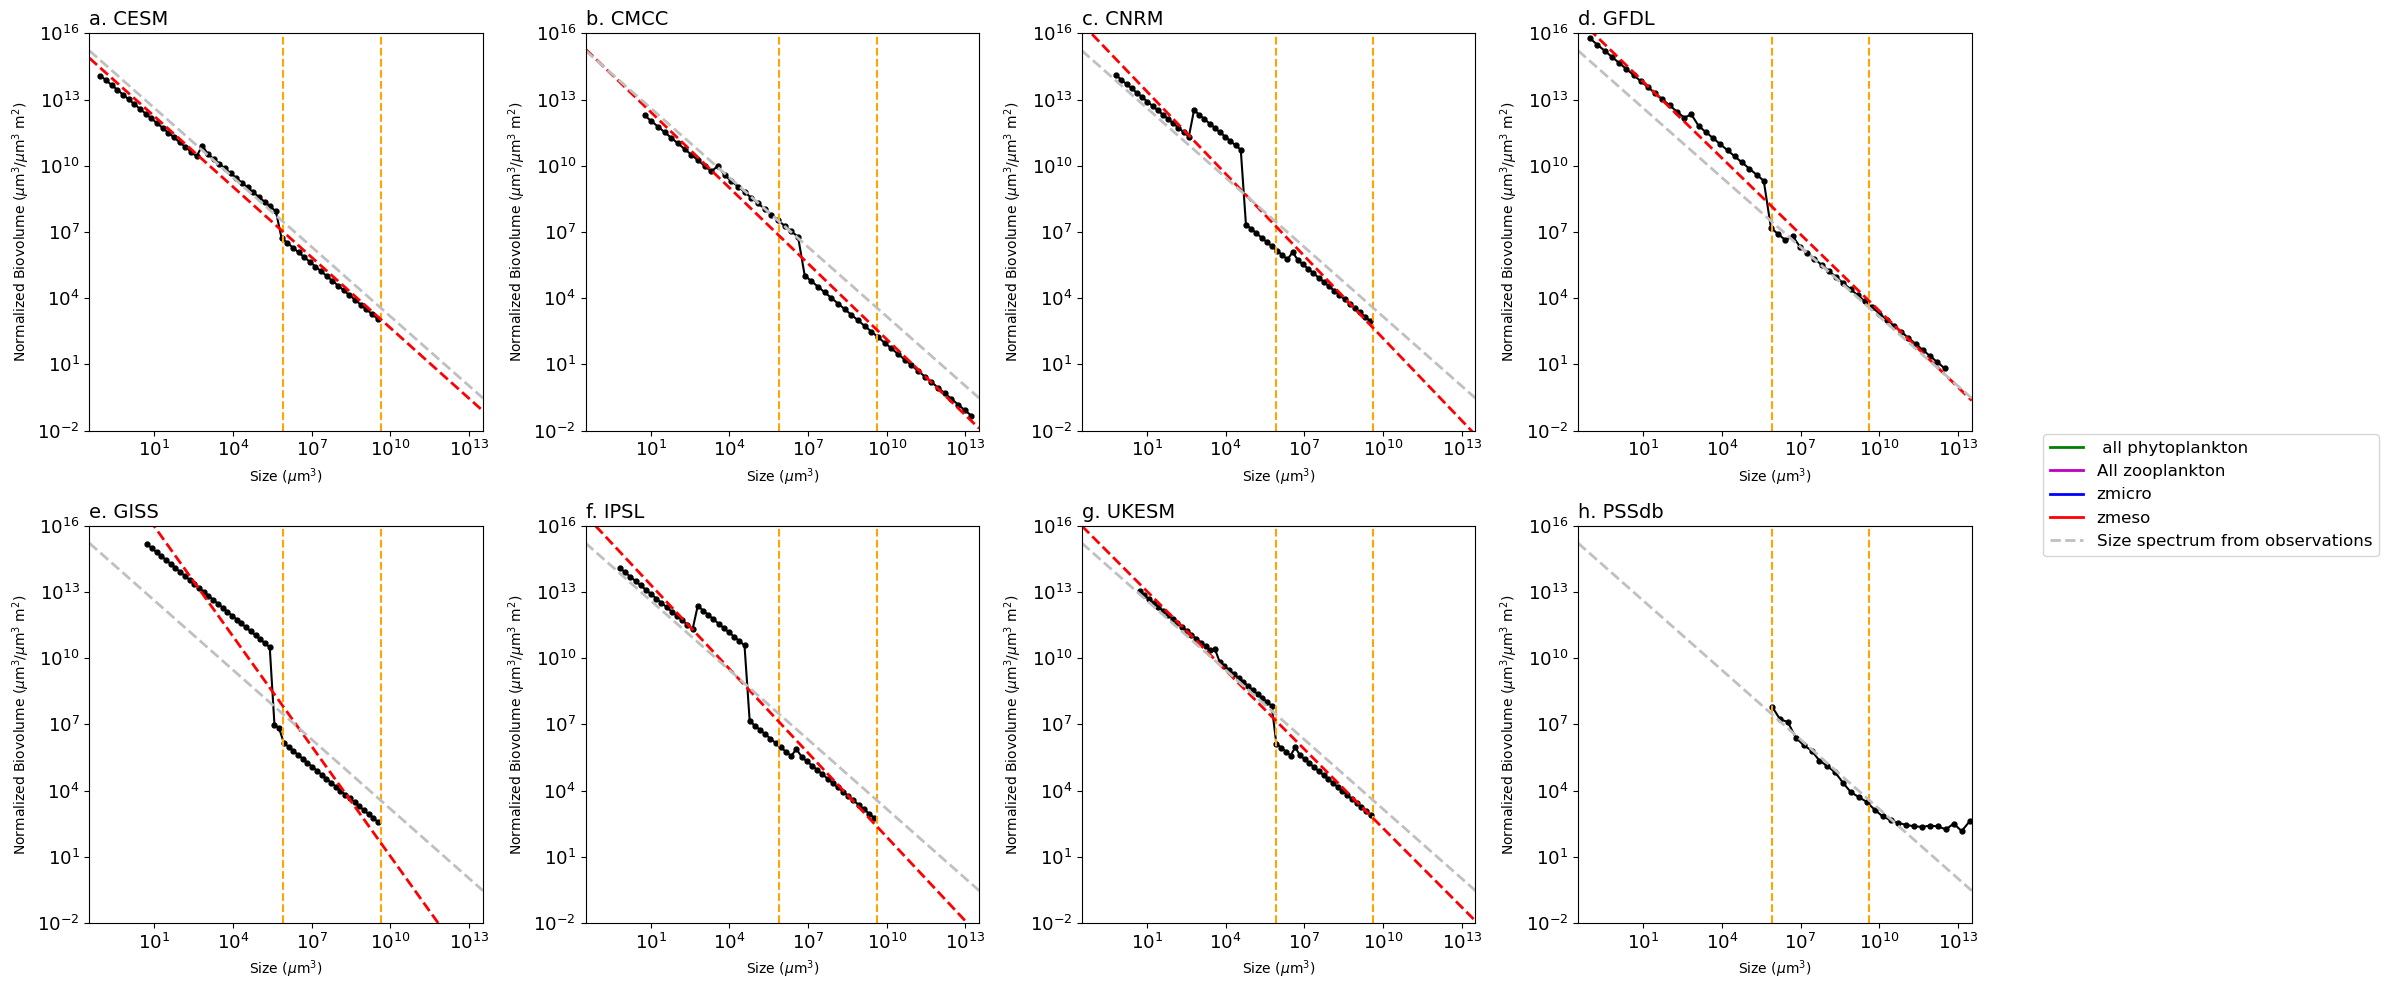

In [50]:
from matplotlib.lines import Line2D
# Define models and panel labels
models = ['CESM', 'CMCC', 'CNRM', 'GFDL', 'GISS', 'IPSL', 'UKESM', 'PSSdb']
letters = ['a.', 'b.', 'c.', 'd.', 'e.', 'f.', 'g.', 'h.']

# Create 2x4 subplot grid
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(20, 10))
axes = axes.flatten()  # Flatten to index easily

# Loop over models and axes
for idx, model in enumerate(models):
    ax = axes[idx]

    df_full = NBSS_dict_full[model]
    #df_subset = NBSS_dict_subset[model]

    # Red dashed full line with markers
    ax.plot(df_full['bin_centers_biovol'], df_full['NB'],
            'k-', marker='o', markersize=3.5, label='Full')

    # Blue solid subset line
    #ax.plot(df_subset['bin_centers_biovol'], df_subset['NB'], color = 'orange', linestyle='-', label='Subset')

    # Vertical orange lines around subset
    ax.axvline(8.2e5, color='orange', linestyle='--')
    ax.axvline(4.2e9, color='orange', linestyle='--')
    
    # Log scale
    ax.set_xscale('log')
    ax.set_yscale('log')
    
    #Limits of the full range of size classes
    um_min=(4/3)*math.pi*(0.4/2)**3
    um_max=(4/3)*math.pi*(40000/2)**3
    
    #fit of the models
    if model != 'PSSdb':
        m=table_S8_df.median_slope[table_S8_df.models == model].values[0]
        b=table_S8_df.median_intercept[table_S8_df.models == model].values[0]
        x_fit = np.geomspace(um_min, um_max, 200)  # evenly spaced on log-x
        y_fit = b * x_fit**m
        ax.plot(x_fit, y_fit, '--', linewidth=2, color='red')

    # Linear regression (log-log) on full data
    # --- Fixed size-spectrum line across all panels ---
    m_PSSdb = -1.05
    b_PSSdb = 4.65e13  # since intercept = log10(3.70e13)


    #xpos = df_full.loc[df_full['bin_centers_biovol'] > 0, 'bin_centers_biovol']
    x_fit_PSSdb = np.geomspace(um_min, um_max, 200)  # evenly spaced on log-x
    y_fit_PSSdb = b_PSSdb * x_fit**m_PSSdb

    ax.plot(x_fit_PSSdb, y_fit_PSSdb, '--', linewidth=2, color='silver')

    # Panel label and title
    ax.set_title(f"{letters[idx]} {model}", loc='left', fontsize=14)

    ax.set_xlabel(r'Size ($\mu$m$^3$)', fontsize=10)
    ax.set_ylabel(r'Normalized Biovolume ($\mu$m$^3$/$\mu$m$^3$ m$^2$)', fontsize=10)
    ax.tick_params(axis='both', labelsize=13)

    ax.set_xlim(um_min, um_max)
    ax.set_ylim(0.01, 1e16)
    

# Custom legend handles for horizontal bars
custom_lines = [
    Line2D([0], [0], color='g', lw=2, linestyle='-', label=' all phytoplankton'),
    Line2D([0], [0], color='m', lw=2, linestyle='-', label='All zooplankton'),
    Line2D([0], [0], color='b', lw=2, linestyle='-', label='zmicro'),
    Line2D([0], [0], color='r', lw=2, linestyle='-', label='zmeso'),
    Line2D([0], [0], color='silver', lw=2, linestyle='--', label='Size spectrum from observations')
]

# Add legend to figure (outside or inside a panel — you choose)
fig.legend(handles=custom_lines, title='',
           loc='center left', bbox_to_anchor=(1.02, 0.5), fontsize=12, title_fontsize=13)


output_path = '/Users/mc4214/GIT/CMIP6_size_spectra/figures/fig_supp_biovol_discrepancy_ver2.png'

plt.tight_layout()
fig.savefig(output_path, dpi=300, bbox_inches='tight')  # This preserves legend
plt.show()  